## Cassegrain Telescope ##

In [29]:
addpath(genpath('../../'));
pwd



ans = '/Users/jeremy/Downloads/work/prtLab/docs/source'

Here we do some analysis of a Cassegrain System to Exercise some of the features of prtLab.  First let's load this example, which consists of two mirrors.

In [30]:
T = exampleCassegrainTelescope();

disp(T);

    Radius     Thickness     SurfaceType     SurfaceData     MaterialType     IndexData        AxisData      CoatingData 
    _______    _________    _____________    ____________    ____________    ____________    ____________    ____________

      -5688           0     "odd_asphere"    {1x1 struct}    "isotropic"     {1x1 struct}    {1x1 struct}    {1x1 struct}
    -1228.3     -2317.8     "odd_asphere"    {1x1 struct}    "isotropic"     {1x1 struct}    {1x1 struct}    {1x1 struct}
        Inf      3674.8     "plane"          {1x1 struct}    "isotropic"     {1x1 struct}    {1x1 struct}    {1x1 struct}
        Inf           0     "medium"         {1x1 struct}    "isotropic"     {1x1 struct}    {1x1 struct}    {1x1 struct}



The mirrors are not odd apsheres, but they do have conics so the iterative ray tracing to find the surface intersection points works.  

Here is a simple plot of the system.

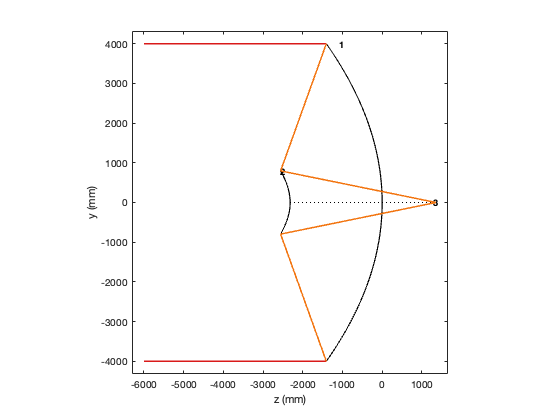

In [31]:
k0 = [0; 0; 1];
x0 = [0; 4000;-6000];
x1 = [0; -4000;-6000];
d1 = polarizationRayTrace(T,k0,x0,[1;0]);
options = d1.options;
options.minAmplitude = .05;
d1 = polarizationRayTrace(T,k0,x0,[1;0], options);
d2 = polarizationRayTrace(T,k0,x1,[1;0], options);
Tplot = updateClearAperturesFromRayTrace(T, {d1,d2});
figure;plotPrtLensCrossSection(Tplot)
plotPrtRayTrace({d1,d2});

For this system, we want to compute the Jones Pupils for this system to see the impact of polarization aberrations due to reflection from the Aluminum mirrors.



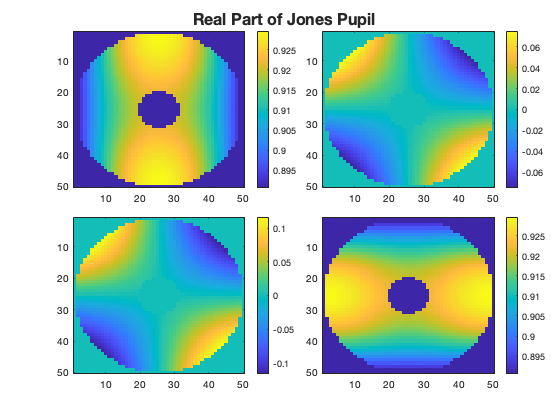

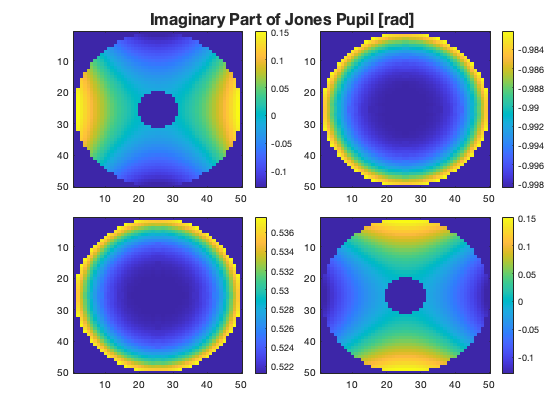

In [32]:
d = 4161.65; 
[X,Y] = meshgrid(linspace(-d,d,50)); % assume 10mm diameter pupil
[~,RHO] = cart2pol(X,Y);
ftr = RHO>=1000 & RHO<=d; % 
E_in = [1;0];
k_in = [0; 0; 1];
Jall = nan([size(X), 2, 2]);
OPL = nan(size(X));

coord = struct('type',"doublePole", ...
    'a_loc',k_in, ...
    'x_o',[1;0;0]);

for ii=1:size(X,1)
    for jj=1:size(X,2)
        pos_in = [X(ii,jj); Y(ii,jj); -6000];
        rayOutput = polarizationRayTrace(T, k_in, pos_in, E_in);
        if ~isempty(rayOutput.finalRayIds)
            finalRay = selectDominantFinalRay(rayOutput);
            P_tot = finalRay.P;
            J = transformPtoJones(P_tot, k_in, finalRay.k, coord);
            Jall(ii,jj,:,:) = J;
            OPL(ii,jj) = finalRay.OPL;
        end
    end
end

figure;plotJonesPupil(Jall,ftr);

Here the machinery of the polarization transfer matrices show the impact of angle dependent Fresnel reflection on the transfer function of the system.  Of particular note is the astigmatism seen in the off diagonal terms.

There are a few ways to study this.  One way would be to make the mirrors perfect.  We can approximate this by making the mirrors index of refracation approach infinity: 

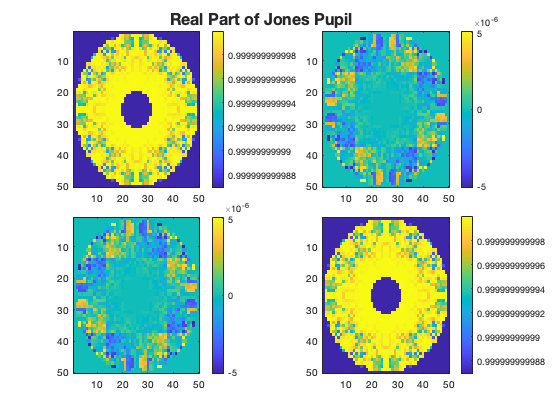

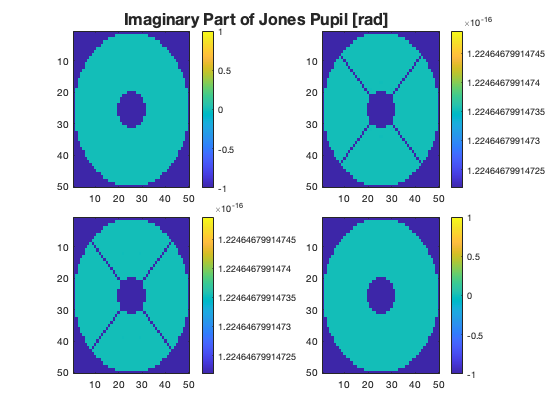

In [33]:

T.IndexData{2}.n = 1E15;
T.IndexData{3}.n = 1E15;

for ii=1:size(X,1)
    for jj=1:size(X,2)
        pos_in = [X(ii,jj); Y(ii,jj); -6000];
        rayOutput = polarizationRayTrace(T, k_in, pos_in, E_in);
        if ~isempty(rayOutput.finalRayIds)
            finalRay = selectDominantFinalRay(rayOutput);
            P_tot = finalRay.P;
            J = transformPtoJones(P_tot, k_in, finalRay.k, coord);
            Jall(ii,jj,:,:) = J;
        end
    end
end

figure;plotJonesPupil(Jall, ftr);

You can see that with a perfect mirror, the imaginary parts of the Jones terms are esssentially 0, and the diagonal terms are essentially 1.  So there are no polarization aberrations, "proving" that this behavior is caused by the metal reflection.  

You might ask why the imaginary part is identially 0. Aren't there OPD differences across the pupil?  The answer is yes, but the P matrices do not have this information encoded.  You could add it, but due to phase wrapping the result will not be useful.  It is possible to look at the OPD separately, by extracing the final ray OPD for each launched ray. 

Another way to check this is to use a different metal.  Let's try gold:

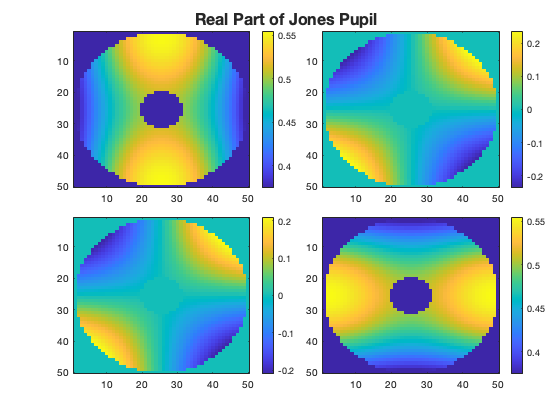

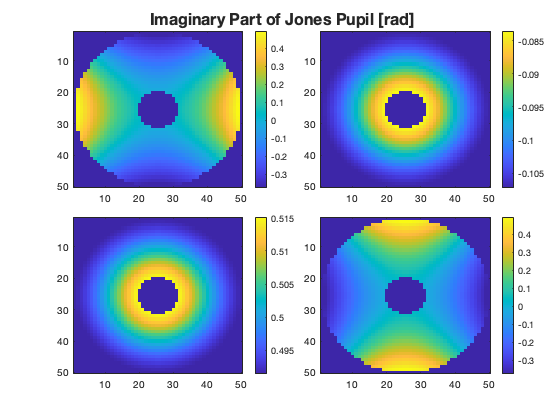

In [34]:
n_gold = 0.8 + 1.8*sqrt(-1);

T.IndexData{2}.n = n_gold;
T.IndexData{3}.n = n_gold;

for ii=1:size(X,1)
    for jj=1:size(X,2)
        pos_in = [X(ii,jj); Y(ii,jj); -6000];
        rayOutput = polarizationRayTrace(T, k_in, pos_in, E_in);
        if ~isempty(rayOutput.finalRayIds)
            finalRay = selectDominantFinalRay(rayOutput);
            P_tot = finalRay.P;
            J = transformPtoJones(P_tot, k_in, finalRay.k, coord);
            Jall(ii,jj,:,:) = J;
        end
    end
end

figure;plotJonesPupil(Jall, ftr);

You can see that the magnitude of the phase error is a function of the mirror material, which is further evidence that this behavior is dominated by Fresnel reflection induced aberrations.

You can do other calcs with this, such as looking at Maltese Cross Pattern vs Incident Polarization.  But for now I will stop here.

